# Chicago Neurodiversity Service Access Analysis

## Introduction

This project examines whether neurodiversity-related child services in Chicago are distributed evenly across neighborhoods, or whether areas facing greater socioeconomic hardship also experience lower access to services. To investigate this question, we combine OpenStreetMap service-location data, Chicago community area boundaries, and neighborhood hardship indicators.

Because OpenStreetMap does not directly classify “neurodiversity services,” we construct a proxy measure using healthcare tags and service-name keywords related to speech therapy, occupational therapy, psychology, autism, developmental support, and other child-focused care services.

The analysis proceeds in four stages. First, we construct a community-area-level dataset of service access by assigning service locations to Chicago community areas and calculating service density. Second, we use exploratory data analysis (EDA) to examine how service availability varies across neighborhoods. Third, we use SQL queries and grouped summaries to identify potential service deserts and compare socioeconomic conditions across neighborhoods. Finally, we apply simple statistical models—including linear regression and logistic regression—to evaluate whether socioeconomic indicators help explain variation in service density and predict the likelihood that a neighborhood is a service desert.

Overall, this project provides an initial descriptive analysis of geographic inequality in access to developmental and therapeutic services across Chicago neighborhoods.

## Data Sources and Methodology

This project combines three datasets:

1. **OpenStreetMap / Overpass API**: service locations in Chicago that may correspond to neurodiversity-related care.
2. **Chicago Community Area Boundaries**: used to spatially assign services to neighborhoods.
3. **Chicago Hardship Index Dataset**: provides neighborhood socioeconomic indicators including poverty, unemployment, education, income, and hardship index.

To compare neighborhoods fairly, we normalize service counts by geographic size and calculate **services per square kilometer**. We also construct two service desert definitions to test robustness:
- **Desert Zero**: neighborhoods with zero broad-proxy service density.
- **Desert Rank25**: neighborhoods in the bottom quartile of service density.

In [1]:
import requests
import pandas as pd
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json
!pip install geopandas
import geopandas as gpd
import numpy as np
import warnings
!pip install geopandas contextily

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.5/37.5 MB 75.5 MB/s  0:00:00m0:00:0100:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━ 4/7 [rasterio]  WARNING: The script rio is installed in '/home/hqt769/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [contextily]7 [contextily]


# Section 1: OpenStreetMap Services via Overpass API

Overpass is an API that lets you query OpenStreetMap data using a query language called Overpass QL and it returns JSON which we can turn into a dataframe. We find the area for "Chicago" and then query objects inside that area that are places likely to provide services for neurodivergent kids. We express that as tags. 

## Defines the Overpass endpoint and our User-Agent and Writes the Overpass QL query for the Chicago Boundary + tags

In [2]:
OVERPASS_URL = "https://overpass-api.de/api/interpreter"

query = """
[out:json][timeout:60];
area["name"="Chicago"]["boundary"="administrative"]["admin_level"="8"]->.chi;

(
  nwr(area.chi)["amenity"="clinic"];
  nwr(area.chi)["amenity"="doctors"];
  nwr(area.chi)["healthcare"="psychotherapist"];
  nwr(area.chi)["healthcare"="speech_therapist"];
  nwr(area.chi)["healthcare"="occupational_therapist"];
  nwr(area.chi)["healthcare"="physiotherapist"];
  nwr(area.chi)["healthcare"="psychology"];
);

out center tags;
"""

resp = requests.get(
    OVERPASS_URL,
    params={"data": query},
    headers={"User-Agent": "UChicago-Data-Project/1.0 (contact: jyugen@uchicago.edu)"}
)
resp.raise_for_status()
data = resp.json()

rows = []
for el in data.get("elements", []):
    tags = el.get("tags", {})
    lat = el.get("lat") or (el.get("center") or {}).get("lat")
    lon = el.get("lon") or (el.get("center") or {}).get("lon")

    rows.append({
        "osm_type": el.get("type"),
        "osm_id": el.get("id"),
        "name": tags.get("name"),
        "amenity": tags.get("amenity"),
        "healthcare": tags.get("healthcare"),
        "website": tags.get("website"),
        "phone": tags.get("phone"),
        "addr_postcode": tags.get("addr:postcode"),
        "lat": lat,
        "lon": lon
    })

df_services = pd.DataFrame(rows)
df_services.head()

,osm_type,osm_id,name,amenity,healthcare,website,phone,addr_postcode,lat,lon
0,node,463772325,AMITA Sage Medical Group,doctors,doctor,NaN,NaN,NaN,41.925702,-87.658009
1,node,1585425015,Weissbluth Pediatrics,clinic,clinic,NaN,NaN,60647,41.925020,-87.687425
2,node,1657357226,Family Planning Associates,clinic,clinic,https://www.fpachicago.com,+1-312-707-8988,NaN,41.882991,-87.644827
3,node,1780030542,Crystal Optical,doctors,doctor,NaN,NaN,NaN,41.924710,-87.721423
4,node,2169693666,Immediate MD,clinic,clinic,NaN,NaN,60614,41.919066,-87.660191


### Writes the Query QL query with Chicago Boundary and Tags

This finds the administrative area called Chicago and then stores it as .chi
Pulls any Node, Way, or Relation (nwr) inside Chicago that matches the listed tags
Returns JSON with tags (to find services relevant to neurodivergent kids like therapy and clinics) and a usable location (out center)

### API Success check

In [3]:
df_services.shape, df_services["lat"].notna().mean(), df_services["name"].notna().mean()

((346, 10), np.float64(1.0), np.float64(0.9797687861271677))

### Saves as CSV 

In [4]:
df_services.to_csv("chicago_osm_services_raw.csv", index=False)

### API pull evidence cell, show request + response basics

In [5]:
# --- API pull evidence (what we called, and what we got back) ---
print("Request URL used by requests:")
print(resp.url)

print("\nHTTP status code:", resp.status_code)
print("Content-Type:", resp.headers.get("Content-Type"))

elements = data.get("elements", [])
print("\nNumber of elements returned:", len(elements))

# show the first element keys to prove structure
if elements:
    print("\nKeys in first element:", elements[0].keys())
    print("Tags in first element (sample):", list((elements[0].get("tags") or {}).keys())[:15])

Request URL used by requests:
https://overpass-api.de/api/interpreter?data=%0A%5Bout%3Ajson%5D%5Btimeout%3A60%5D%3B%0Aarea%5B%22name%22%3D%22Chicago%22%5D%5B%22boundary%22%3D%22administrative%22%5D%5B%22admin_level%22%3D%228%22%5D-%3E.chi%3B%0A%0A%28%0A++nwr%28area.chi%29%5B%22amenity%22%3D%22clinic%22%5D%3B%0A++nwr%28area.chi%29%5B%22amenity%22%3D%22doctors%22%5D%3B%0A++nwr%28area.chi%29%5B%22healthcare%22%3D%22psychotherapist%22%5D%3B%0A++nwr%28area.chi%29%5B%22healthcare%22%3D%22speech_therapist%22%5D%3B%0A++nwr%28area.chi%29%5B%22healthcare%22%3D%22occupational_therapist%22%5D%3B%0A++nwr%28area.chi%29%5B%22healthcare%22%3D%22physiotherapist%22%5D%3B%0A++nwr%28area.chi%29%5B%22healthcare%22%3D%22psychology%22%5D%3B%0A%29%3B%0A%0Aout+center+tags%3B%0A

HTTP status code: 200
Content-Type: application/json

Number of elements returned: 346

Keys in first element: dict_keys(['type', 'id', 'lat', 'lon', 'tags'])
Tags in first element (sample): ['amenity', 'healthcare', 'name']


### Saves the raw JSON for our audit trail

In [6]:
with open("overpass_chicago_services_raw.json", "w") as f:
    json.dump(data, f)

print("Saved raw API response to overpass_chicago_services_raw.json")

Saved raw API response to overpass_chicago_services_raw.json


### Data Quality Checks
Checks for missing data, validity checks via grouped summaries and oddities checks via missingness and dupes

In [7]:
print("Shape:", df_services.shape)

print("\nMissingness (percent):")
print((df_services.isna().mean() * 100).round(2).sort_values(ascending=False))

df_services["has_location"] = df_services["lat"].notna() & df_services["lon"].notna()
print("\nShare with coordinates:", df_services["has_location"].mean().round(3))

print("\nDuplicate OSM records:", df_services.duplicated(subset=["osm_type", "osm_id"]).sum())

print("\nTop amenity values:")
print(df_services["amenity"].value_counts(dropna=False).head(10))

print("\nTop healthcare values:")
print(df_services["healthcare"].value_counts(dropna=False).head(10))

Shape: (346, 10)

Missingness (percent):
phone            73.70
website          66.18
addr_postcode    24.86
amenity          20.23
name              2.02
osm_type          0.00
osm_id            0.00
healthcare        0.00
lat               0.00
lon               0.00
dtype: float64

Share with coordinates: 1.0

Duplicate OSM records: 0

Top amenity values:
amenity
clinic     216
NaN         70
doctors     60
Name: count, dtype: int64

Top healthcare values:
healthcare
clinic                                 172
doctor                                  60
physiotherapist                         53
dialysis                                35
psychotherapist                         18
counselling                              4
birthing_centre                          1
lice_removal                             1
clinic;sample_collection;laboratory      1
speech_therapist                         1
Name: count, dtype: int64


### Makes it reproducible and saves as to CSV
Makes it easy to load into SQLite for SQl queries

In [8]:
df_services.to_csv("chicago_osm_servicesSQL.csv", index=False)
print("Saved to chicago_osm_services.csv")

Saved to chicago_osm_services.csv


### Adding neurodiversity related filter flags to tag for service names

In [9]:
keywords = [
    "autism", "aba", "occupational", "speech", "sensory", "development",
    "behavior", "behaviour", "neuro", "pediatric", "child", "children"
]

pattern = re.compile("|".join(keywords), re.IGNORECASE)

df_services["name_clean"] = df_services["name"].fillna("").str.lower()
df_services["nd_name_flag"] = df_services["name"].fillna("").apply(lambda x: bool(pattern.search(x)))

df_services[["name", "amenity", "healthcare", "nd_name_flag", "lat", "lon"]].head(25)

,name,amenity,healthcare,nd_name_flag,lat,lon
0,AMITA Sage Medical Group,doctors,doctor,False,41.925702,-87.658009
1,Weissbluth Pediatrics,clinic,clinic,True,41.925020,-87.687425
2,Family Planning Associates,clinic,clinic,False,41.882991,-87.644827
3,Crystal Optical,doctors,doctor,False,41.924710,-87.721423
4,Immediate MD,clinic,clinic,False,41.919066,-87.660191
5,Athletico Physical Therapy,doctors,physiotherapist,False,41.955015,-87.749918
6,Immediate MD,clinic,clinic,False,41.952571,-87.688107
7,Physicians Immediate Care,doctors,doctor,False,41.911059,-87.632600
8,Andersonville Behavioral Health,NaN,psychotherapist,True,41.977889,-87.668800
9,Illinois Bone & Joint Institute,clinic,clinic,False,41.934678,-87.697360


In [10]:
df_services["nd_name_flag"].value_counts(dropna=False)

nd_name_flag
False    326
True      20
Name: count, dtype: int64

## Initial EDA table : Services per type and nd flag

In [11]:
# Counts by healthcare tag and nd flag
eda_table = (df_services
             .groupby(["healthcare", "nd_name_flag"])
             .size()
             .reset_index(name="count")
             .sort_values("count", ascending=False))

eda_table.head(20)

,healthcare,nd_name_flag,count
1,clinic,False,165
9,physiotherapist,False,53
6,doctor,False,50
5,dialysis,False,35
10,psychotherapist,False,16
7,doctor,True,10
2,clinic,True,7
4,counselling,False,4
11,psychotherapist,True,2
3,clinic;sample_collection;laboratory,False,1


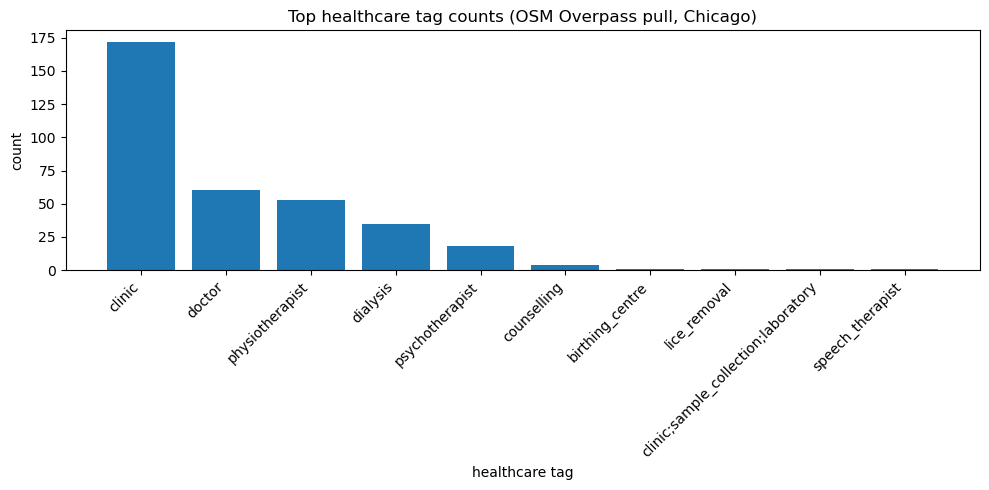

In [12]:
# Quick matplotlib: Top Healthcare Tag Counts

counts = df_services["healthcare"].fillna("missing").value_counts().head(10)
plt.figure(figsize=(10,5))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Top healthcare tag counts (OSM Overpass pull, Chicago)")
plt.xlabel("healthcare tag")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## How we defined “neurodiversity-related child services” (proxy)
We built a services dataset for Chicago using the OpenStreetMap Overpass API and then classified services using a proxy rule because OpenStreetMap is not specifically designed to tag “neurodiversity services.” Our proxy combines (1) specific healthcare tags that frequently correspond to developmental supports (for example speech therapy, occupational therapy, psychology, psychotherapy), and (2) keyword matches in the service name (for example autism, ABA, developmental, sensory, neuro, pediatric, child/children).

## We created two versions of the proxy:
Strict ND proxy: name contains explicit ND keywords (for example “autism”, “ABA”).
Broad ND proxy: strict ND keywords OR therapy-related healthcare tags (speech/OT/psychology, etc.).
This approach is descriptive and likely undercounts services where OSM tags are missing or names are generic. We treat it as an access proxy, not a clinical or licensing classification.

In [13]:
# 1) Basic cleanup (keeps our existing df_services, just improves it for nd)
df_services = df_services.copy()

df_services["has_location"] = df_services["lat"].notna() & df_services["lon"].notna()
df_services = df_services[df_services["has_location"]].copy()

df_services = df_services.drop_duplicates(subset=["osm_type", "osm_id"])

for col in ["name", "amenity", "healthcare"]:
    df_services[col] = df_services[col].astype("string")

# 2) Safer keyword flag (keeps our idea, makes it more robust)
keywords = [
    "autism", "aba", "sensory", "development", "developmental",
    "neuro", "adhd", "special needs", "early intervention",
    "occupational", "speech", "behavior", "behaviour",
    "pediatric", "child", "children"
]

pattern = re.compile("|".join(re.escape(k) for k in keywords), re.IGNORECASE)

df_services["name_clean"] = df_services["name"].fillna("").str.lower()
df_services["nd_name_flag"] = df_services["name"].fillna("").apply(lambda x: bool(pattern.search(str(x))))

# 3) Tag-based therapy flag (so we're not relying only on names)
therapy_healthcare_tags = {
    "speech_therapist",
    "occupational_therapist",
    "physiotherapist",
    "psychotherapist",
    "psychology"
}

df_services["therapy_tag_flag"] = df_services["healthcare"].isin(therapy_healthcare_tags)

# 4) Final proxy definitions (this is the "defensible rule" part)
df_services["nd_related_strict"] = df_services["nd_name_flag"].astype(int)
df_services["nd_related_broad"] = (df_services["nd_name_flag"] | df_services["therapy_tag_flag"]).astype(int)

# 5) Quick checks
print("Rows after cleanup:", df_services.shape[0])
print("Share strict ND:", df_services["nd_related_strict"].mean().round(3))
print("Share broad ND:", df_services["nd_related_broad"].mean().round(3))

df_services[["name", "amenity", "healthcare", "nd_related_strict", "nd_related_broad", "lat", "lon"]].head(25)

Rows after cleanup: 346
Share strict ND: 0.058
Share broad ND: 0.257


,name,amenity,healthcare,nd_related_strict,nd_related_broad,lat,lon
0,AMITA Sage Medical Group,doctors,doctor,0,0,41.925702,-87.658009
1,Weissbluth Pediatrics,clinic,clinic,1,1,41.925020,-87.687425
2,Family Planning Associates,clinic,clinic,0,0,41.882991,-87.644827
3,Crystal Optical,doctors,doctor,0,0,41.924710,-87.721423
4,Immediate MD,clinic,clinic,0,0,41.919066,-87.660191
5,Athletico Physical Therapy,doctors,physiotherapist,0,1,41.955015,-87.749918
6,Immediate MD,clinic,clinic,0,0,41.952571,-87.688107
7,Physicians Immediate Care,doctors,doctor,0,0,41.911059,-87.632600
8,Andersonville Behavioral Health,<NA>,psychotherapist,1,1,41.977889,-87.668800
9,Illinois Bone & Joint Institute,clinic,clinic,0,0,41.934678,-87.697360


In [14]:
# Save cleaned + flagged services dataset for downstream use (SQLite, joins, mapping)
output_path = "chicago_osm_services_clean_ndproxy.csv"
df_services.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print("Rows:", df_services.shape[0], "Columns:", df_services.shape[1])

Saved: chicago_osm_services_clean_ndproxy.csv
Rows: 346 Columns: 16


# Section 2: Data Sources and Construction of Neighborhood Service Access Metrics
This section builds the neighborhood-level dataset used for analysis. We (1) pulled service locations in Chicago from OpenStreetMap using the Overpass API, and now we will (2) attach each service to a Chicago community area boundary, (3) merge in neighborhood demographics, and (4) create service access metrics such as services per square kilometer. Because OpenStreetMap tagging is incomplete and not designed specifically for neurodiversity services, we treat our service definition as a proxy and document the filtering logic and limitations.

## Dataset 2: Chicago community areas boundaries

In [15]:
COMMUNITY_AREAS_URL = "https://data.cityofchicago.org/resource/igwz-8jzy.geojson"

In [84]:
##Calls the API and confirms

resp = requests.get(COMMUNITY_AREAS_URL, headers={"User-Agent": "UChicago-Data-Project/1.0 (contact: jyugen@uchicago.edu)"}, timeout=120)
resp.raise_for_status()

print("Status:", resp.status_code)
print("Content-Type:", resp.headers.get("Content-Type"))
print("First 300 chars of response:")
print(resp.text[:300])

Status: 200
Content-Type: application/vnd.geo+json; charset=UTF-8
First 300 chars of response:
{ "type": "FeatureCollection", "features": [{"type":"Feature","geometry":{"type":"MultiPolygon","coordinates":[[[[-87.65455590025104,41.99816614970252],[-87.65573692713699,41.99817520952651],[-87.65577334679872,41.99819571036795],[-87.65580429073043,41.998209147443845],[-87.65584690994521,41.9982213


In [17]:
gdf_areas = gpd.read_file(COMMUNITY_AREAS_URL)
gdf_areas.head()

,community,shape_area,area_num_1,area_numbe,shape_len,geometry
0,ROGERS PARK,51259902.4506,1,1,34052.3975757,"MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ..."
1,WEST RIDGE,98429094.8621,2,2,43020.6894583,"MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ..."
2,UPTOWN,65095642.7289,3,3,46972.7945549,"MULTIPOLYGON (((-87.64102 41.9548, -87.644 41...."
3,LINCOLN SQUARE,71352328.2399,4,4,36624.6030848,"MULTIPOLYGON (((-87.67441 41.9761, -87.6744 41..."
4,NORTH CENTER,57054167.85,5,5,31391.6697542,"MULTIPOLYGON (((-87.67336 41.93234, -87.67342 ..."


In [18]:
gdf_areas.columns

Index(['community', 'shape_area', 'area_num_1', 'area_numbe', 'shape_len',
       'geometry'],
      dtype='str')

In [19]:
# Keeps only what we need and standardize column names
gdf_areas_clean = gdf_areas[["area_numbe", "community", "geometry"]].copy()
gdf_areas_clean = gdf_areas_clean.rename(columns={
    "area_numbe": "area_num",
    "community": "area_name"
})

# Ensure area_num is numeric
gdf_areas_clean["area_num"] = gdf_areas_clean["area_num"].astype(int)

gdf_areas_clean.head()

,area_num,area_name,geometry
0,1,ROGERS PARK,"MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ..."
1,2,WEST RIDGE,"MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ..."
2,3,UPTOWN,"MULTIPOLYGON (((-87.64102 41.9548, -87.644 41...."
3,4,LINCOLN SQUARE,"MULTIPOLYGON (((-87.67441 41.9761, -87.6744 41..."
4,5,NORTH CENTER,"MULTIPOLYGON (((-87.67336 41.93234, -87.67342 ..."


### Converts our services dataframe into a GeoDataFrame (geographic points), to do a spatial join into polygons

In [20]:
gdf_services = gpd.GeoDataFrame(
    df_services.copy(),
    geometry=gpd.points_from_xy(df_services["lon"], df_services["lat"]),
    crs="EPSG:4326"
)

gdf_services.head()

,osm_type,osm_id,name,amenity,healthcare,website,phone,addr_postcode,lat,lon,has_location,name_clean,nd_name_flag,therapy_tag_flag,nd_related_strict,nd_related_broad,geometry
0,node,463772325,AMITA Sage Medical Group,doctors,doctor,NaN,NaN,NaN,41.925702,-87.658009,True,amita sage medical group,False,False,0,0,POINT (-87.65801 41.9257)
1,node,1585425015,Weissbluth Pediatrics,clinic,clinic,NaN,NaN,60647,41.925020,-87.687425,True,weissbluth pediatrics,True,False,1,1,POINT (-87.68743 41.92502)
2,node,1657357226,Family Planning Associates,clinic,clinic,https://www.fpachicago.com,+1-312-707-8988,NaN,41.882991,-87.644827,True,family planning associates,False,False,0,0,POINT (-87.64483 41.88299)
3,node,1780030542,Crystal Optical,doctors,doctor,NaN,NaN,NaN,41.924710,-87.721423,True,crystal optical,False,False,0,0,POINT (-87.72142 41.92471)
4,node,2169693666,Immediate MD,clinic,clinic,NaN,NaN,60614,41.919066,-87.660191,True,immediate md,False,False,0,0,POINT (-87.66019 41.91907)


### Checks to make sure both layers are in the same coordinate system (CRS)

In [21]:
# Reproject areas to match services if needed
if gdf_areas_clean.crs != gdf_services.crs:
    gdf_areas_clean = gdf_areas_clean.to_crs(gdf_services.crs)

gdf_areas_clean.crs, gdf_services.crs

(<Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich,
 <Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich)

### Spatial join, assigns each service to a community area

In [22]:
gdf_services_with_area = gpd.sjoin(
    gdf_services,
    gdf_areas_clean,
    how="left",
    predicate="within"
)

gdf_services_with_area[["name", "healthcare", "amenity", "area_num", "area_name"]].head(10)

,name,healthcare,amenity,area_num,area_name
0,AMITA Sage Medical Group,doctor,doctors,7,LINCOLN PARK
1,Weissbluth Pediatrics,clinic,clinic,22,LOGAN SQUARE
2,Family Planning Associates,clinic,clinic,28,NEAR WEST SIDE
3,Crystal Optical,doctor,doctors,22,LOGAN SQUARE
4,Immediate MD,clinic,clinic,7,LINCOLN PARK
5,Athletico Physical Therapy,physiotherapist,doctors,15,PORTAGE PARK
6,Immediate MD,clinic,clinic,5,NORTH CENTER
7,Physicians Immediate Care,doctor,doctors,8,NEAR NORTH SIDE
8,Andersonville Behavioral Health,psychotherapist,<NA>,77,EDGEWATER
9,Illinois Bone & Joint Institute,clinic,clinic,21,AVONDALE


### Checks how many services did not match an area

In [23]:
match_rate = gdf_services_with_area["area_num"].notna().mean()
unmatched = gdf_services_with_area["area_num"].isna().sum()

print("Match rate:", round(match_rate, 3))
print("Unmatched services:", unmatched)

Match rate: 1.0
Unmatched services: 0


### Aggregate to neighborhood-level service counts
### Builds the community area, nd_services and total services tables, so we can anchor table for merging demographics and computing services per square kilometer

In [24]:
area_services = (gdf_services_with_area
    .dropna(subset=["area_num"])
    .groupby(["area_num", "area_name"])
    .agg(
        nd_services_broad=("nd_related_broad", "sum"),
        nd_services_strict=("nd_related_strict", "sum"),
        total_services=("osm_id", "count")
    )
    .reset_index()
    .sort_values("nd_services_broad", ascending=False)
)

area_services.head(15)

,area_num,area_name,nd_services_broad,nd_services_strict,total_services
4,5,NORTH CENTER,13,4,20
26,28,NEAR WEST SIDE,8,5,28
2,3,UPTOWN,8,1,18
6,7,LINCOLN PARK,7,1,20
20,22,LOGAN SQUARE,5,2,18
31,33,NEAR SOUTH SIDE,4,1,8
22,24,WEST TOWN,4,0,20
3,4,LINCOLN SQUARE,4,0,5
5,6,LAKE VIEW,4,1,15
7,8,NEAR NORTH SIDE,3,1,13


In [25]:
# Saves for SQLite
area_services.to_csv("services_by_community_area.csv", index=False)
print("Saved services_by_community_area.csv")

Saved services_by_community_area.csv


## Dataset 3: Neighborhood demographics

In [26]:
### API pull


HARDSHIP_URL = "https://data.cityofchicago.org/resource/kn9c-c2s2.json"
HEADERS = {"User-Agent": "UChicago-Data-Project/1.0 (contact: jyugen@uchicago.edu)"}

resp = requests.get(HARDSHIP_URL, params={"$limit": 5}, headers=HEADERS, timeout=120)
resp.raise_for_status()

print("Request URL:", resp.url)
print("Status:", resp.status_code)
print("Content-Type:", resp.headers.get("Content-Type"))

sample = resp.json()
pd.DataFrame(sample).head()

Request URL: https://data.cityofchicago.org/resource/kn9c-c2s2.json?%24limit=5
Status: 200
Content-Type: application/json;charset=utf-8


,ca,community_area_name,percent_of_housing_crowded,percent_households_below_poverty,percent_aged_16_unemployed,percent_aged_25_without_high_school_diploma,percent_aged_under_18_or_over_64,per_capita_income_,hardship_index
0,1,Rogers Park,7.7,23.6,8.7,18.2,27.5,23939,39
1,2,West Ridge,7.8,17.2,8.8,20.8,38.5,23040,46
2,3,Uptown,3.8,24,8.9,11.8,22.2,35787,20
3,4,Lincoln Square,3.4,10.9,8.2,13.4,25.5,37524,17
4,5,North Center,0.3,7.5,5.2,4.5,26.2,57123,6


In [27]:
### Pull ALL rows with pagination
def socrata_pull_all(url, headers, limit=1000, max_pages=50):
    all_rows = []
    offset = 0

    for _ in range(max_pages):
        resp = requests.get(
            url,
            params={"$limit": limit, "$offset": offset},
            headers=headers,
            timeout=120
        )
        resp.raise_for_status()
        batch = resp.json()

        if not batch:
            break

        all_rows.extend(batch)
        offset += limit

    return pd.DataFrame(all_rows)

df_hardship_raw = socrata_pull_all(HARDSHIP_URL, HEADERS, limit=1000)
df_hardship_raw.shape

(78, 9)

## Clean columns and create the join key area_num

Our services aggregation uses area_num. The hardship dataset uses ca (community area number).

In [28]:
df_hardship = df_hardship_raw.copy()

# Standardize key columns
df_hardship = df_hardship.rename(columns={
    "ca": "area_num",
    "community_area_name": "area_name"
})

# Drop rows without a valid area_num (this also removes weird footer-style rows if any)
df_hardship["area_num"] = pd.to_numeric(df_hardship["area_num"], errors="coerce")
df_hardship = df_hardship.dropna(subset=["area_num"])
df_hardship["area_num"] = df_hardship["area_num"].astype(int)

# Convert numeric columns that came in as strings
num_cols = [
    "percent_of_housing_crowded",
    "percent_households_below_poverty",
    "percent_aged_16_unemployed",
    "percent_aged_25_without_high_school_diploma",
    "percent_aged_under_18_or_over_64",
    "per_capita_income_",
    "hardship_index"
]
for c in num_cols:
    if c in df_hardship.columns:
        df_hardship[c] = pd.to_numeric(df_hardship[c], errors="coerce")

# Keep only what we need
keep_cols = ["area_num", "area_name"] + [c for c in num_cols if c in df_hardship.columns]
df_hardship = df_hardship[keep_cols].copy()

df_hardship.head()

,area_num,area_name,percent_of_housing_crowded,percent_households_below_poverty,percent_aged_16_unemployed,percent_aged_25_without_high_school_diploma,percent_aged_under_18_or_over_64,per_capita_income_,hardship_index
0,1,Rogers Park,7.7,23.6,8.7,18.2,27.5,23939,39
1,2,West Ridge,7.8,17.2,8.8,20.8,38.5,23040,46
2,3,Uptown,3.8,24.0,8.9,11.8,22.2,35787,20
3,4,Lincoln Square,3.4,10.9,8.2,13.4,25.5,37524,17
4,5,North Center,0.3,7.5,5.2,4.5,26.2,57123,6


### Data quality checks

In [29]:
print("Rows:", df_hardship.shape[0])
print("\nMissingness (%):")
print((df_hardship.isna().mean() * 100).round(2).sort_values(ascending=False))

df_hardship.describe(include="all").T.head(15)

Rows: 77

Missingness (%):
area_num                                       0.0
area_name                                      0.0
percent_of_housing_crowded                     0.0
percent_households_below_poverty               0.0
percent_aged_16_unemployed                     0.0
percent_aged_25_without_high_school_diploma    0.0
percent_aged_under_18_or_over_64               0.0
per_capita_income_                             0.0
hardship_index                                 0.0
dtype: float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
area_num,77.0,NaN,NaN,NaN,39.0,22.371857,1.0,20.0,39.0,58.0,77.0
area_name,77,77,Rogers Park,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
percent_of_housing_crowded,77.0,NaN,NaN,NaN,4.923377,3.682887,0.3,2.3,3.8,6.8,15.8
percent_households_below_poverty,77.0,NaN,NaN,NaN,21.766234,11.529957,3.3,13.2,18.9,29.2,56.5
percent_aged_16_unemployed,77.0,NaN,NaN,NaN,15.372727,7.543412,4.7,9.2,13.9,20.0,35.9
percent_aged_25_without_high_school_diploma,77.0,NaN,NaN,NaN,20.341558,11.823152,2.5,11.8,18.5,26.6,54.8
percent_aged_under_18_or_over_64,77.0,NaN,NaN,NaN,35.746753,7.327716,13.5,32.0,38.1,40.5,51.5
per_capita_income_,77.0,NaN,NaN,NaN,25563.168831,15293.098259,8201.0,15754.0,21323.0,28887.0,88669.0
hardship_index,77.0,NaN,NaN,NaN,49.506494,28.690556,1.0,25.0,50.0,74.0,98.0


### Merge with our area_services table

### Includes all 77 areas in df_area: Right now, areas with zero services are missing. For “service desert” analysis, we  want them included as zeros. This uses the hardship table as the base and left join services into it:

In [30]:
# Making sure df_hardship has the column named area_name and area_services also uses area_name, because our prior iterations created those columns with an x and y
assert "area_name" in df_hardship.columns
assert "area_name" in area_services.columns

# Build the full community-area table (keep all 77 areas)
df_area_full = df_hardship.merge(
    area_services,
    on="area_num",
    how="left",
    suffixes=("", "_services")
)

# Fill missing service counts with 0 (these are the missing areas coming back)
for c in ["nd_services_broad", "nd_services_strict", "total_services"]:
    df_area_full[c] = df_area_full[c].fillna(0).astype(int)

# Keep one area_name column (use hardship as source of truth)
# We do this because the merge created a second area name column
if "area_name_services" in df_area_full.columns:
    df_area_full["area_name"] = df_area_full["area_name"].fillna(df_area_full["area_name_services"])
    df_area_full = df_area_full.drop(columns=["area_name_services"])

# Quick sanity checks
print("Rows in df_area_full:", df_area_full.shape[0])
print("How many areas have 0 services (broad):", (df_area_full["nd_services_broad"] == 0).sum())

df_area_full.head()

Rows in df_area_full: 77
How many areas have 0 services (broad): 45


,area_num,area_name,percent_of_housing_crowded,percent_households_below_poverty,percent_aged_16_unemployed,percent_aged_25_without_high_school_diploma,percent_aged_under_18_or_over_64,per_capita_income_,hardship_index,nd_services_broad,nd_services_strict,total_services
0,1,Rogers Park,7.7,23.6,8.7,18.2,27.5,23939,39,1,0,2
1,2,West Ridge,7.8,17.2,8.8,20.8,38.5,23040,46,1,0,3
2,3,Uptown,3.8,24.0,8.9,11.8,22.2,35787,20,8,1,18
3,4,Lincoln Square,3.4,10.9,8.2,13.4,25.5,37524,17,4,0,5
4,5,North Center,0.3,7.5,5.2,4.5,26.2,57123,6,13,4,20


In [31]:
# Which community areas are missing from area_services?
missing_areas = set(df_hardship["area_num"]) - set(area_services["area_num"])
len(missing_areas), sorted(list(missing_areas))[:15]

## 10 community areas exist in the hardship dataset, but your services pull produced zero services mapped to them (or they got filtered out

(10, [9, 34, 44, 45, 53, 54, 57, 66, 67, 76])

### For “service desert” analysis, these are important because they might end up as the lowest access areas. So, we include them as zeros using the df_area_full approach.

In [32]:
name_check = df_hardship[["area_num", "area_name"]].merge(
    area_services[["area_num", "area_name"]],
    on="area_num",
    how="inner",
    suffixes=("_hardship", "_services")
)

name_check["name_match"] = (
    name_check["area_name_hardship"].str.strip().str.lower()
    == name_check["area_name_services"].str.strip().str.lower()
)

name_check["name_match"].value_counts()

name_match
True     65
False     2
Name: count, dtype: int64

In [33]:
name_check.loc[~name_check["name_match"], ["area_num", "area_name_hardship", "area_name_services"]]

,area_num,area_name_hardship,area_name_services
16,18,Montclaire,MONTCLARE
63,73,Washington Height,WASHINGTON HEIGHTS


In [34]:
missing_list = [9, 34, 44, 45, 53, 54, 57, 66, 67, 76]

df_area_full.loc[df_area_full["area_num"].isin(missing_list),
                 ["area_num", "area_name", "nd_services_broad", "total_services"]].sort_values("area_num")

##missing after a merge” can mean “zero,” not “bad data.”

,area_num,area_name,nd_services_broad,total_services
8,9,Edison Park,0,0
33,34,Armour Square,0,0
43,44,Chatham,0,0
44,45,Avalon Park,0,0
52,53,West Pullman,0,0
53,54,Riverdale,0,0
56,57,Archer Heights,0,0
65,66,Chicago Lawn,0,0
66,67,West Englewood,0,0
75,76,O'Hare,0,0


In [35]:
# Tidy a couple known name variants 
name_fixes = {
    "Montclaire": "Montclare",
    "Washington Height": "Washington Heights",
}

df_area_full["area_name"] = df_area_full["area_name"].replace(name_fixes)

In [36]:
df_area_full["area_name"] = df_area_full["area_name"].str.strip()

In [37]:
name_check.loc[~name_check["name_match"], ["area_num", "area_name_hardship", "area_name_services"]]

,area_num,area_name_hardship,area_name_services
16,18,Montclaire,MONTCLARE
63,73,Washington Height,WASHINGTON HEIGHTS


### Recreate a name consistency check using area_services + df_hardship

In [38]:
# Compare names between hardship and area_services
name_check = df_hardship[["area_num", "area_name"]].merge(
    area_services[["area_num", "area_name"]],
    on="area_num",
    how="inner",
    suffixes=("_hardship", "_services")
)

name_check["name_match"] = (
    name_check["area_name_hardship"].str.strip().str.lower()
    == name_check["area_name_services"].str.strip().str.lower()
)

name_check["name_match"].value_counts()

name_match
True     65
False     2
Name: count, dtype: int64

In [39]:
## To view the mismatches
name_check.loc[~name_check["name_match"], ["area_num", "area_name_hardship", "area_name_services"]]

,area_num,area_name_hardship,area_name_services
16,18,Montclaire,MONTCLARE
63,73,Washington Height,WASHINGTON HEIGHTS


In [40]:
name_check = df_hardship[["area_num", "area_name"]].merge(
    area_services[["area_num", "area_name"]],
    on="area_num",
    how="inner",
    suffixes=("_hardship", "_services")
)

mismatches = name_check[
    name_check["area_name_hardship"].str.strip().str.lower()
    != name_check["area_name_services"].str.strip().str.lower()
].copy()

mismatches

,area_num,area_name_hardship,area_name_services
16,18,Montclaire,MONTCLARE
63,73,Washington Height,WASHINGTON HEIGHTS


In [41]:
# Normalize whitespace first
df_area_full["area_name"] = df_area_full["area_name"].astype(str).str.strip()

# Apply targeted fixes by area_num (more reliable than text matching)
df_area_full.loc[df_area_full["area_num"] == 18, "area_name"] = "Montclare"
df_area_full.loc[df_area_full["area_num"] == 73, "area_name"] = "Washington Heights"

In [42]:
df_area_full.loc[df_area_full["area_num"].isin([18, 73]), ["area_num", "area_name"]]

,area_num,area_name
17,18,Montclare
72,73,Washington Heights


#### We joined datasets using community area number. Two area names differed slightly across sources due to spelling conventions, although this did not affect joins or results, we chose to tidy it anyway.

## Feature engineering, uses shape_area from our community areas boundary file to compute service density.

In [43]:
area_size = gdf_areas[["area_numbe", "shape_area"]].copy().rename(columns={"area_numbe": "area_num"})
area_size["area_num"] = area_size["area_num"].astype(int)

df_area_full = df_area_full.merge(area_size, on="area_num", how="left")

df_area_full["shape_area"] = pd.to_numeric(df_area_full["shape_area"], errors="coerce")
df_area_full["area_sq_km"] = df_area_full["shape_area"] / 1_000_000

# shape_area is typically square meters, convert to square kilometers
df_area_full["area_sq_km"] = df_area_full["shape_area"] / 1_000_000
df_area_full["services_per_sq_km_broad"] = df_area_full["nd_services_broad"] / df_area_full["area_sq_km"]
df_area_full["services_per_sq_km_strict"] = df_area_full["nd_services_strict"] / df_area_full["area_sq_km"]

df_area_full[["area_num", "area_name", "nd_services_broad", "area_sq_km", "services_per_sq_km_broad"]].head()

,area_num,area_name,nd_services_broad,area_sq_km,services_per_sq_km_broad
0,1,Rogers Park,1,51.259902,0.019508
1,2,West Ridge,1,98.429095,0.010160
2,3,Uptown,8,65.095643,0.122896
3,4,Lincoln Square,4,71.352328,0.056060
4,5,North Center,13,57.054168,0.227854


In [44]:
df_area_full[["shape_area", "area_sq_km"]].describe()
df_area_full["area_sq_km"].isna().sum()

np.int64(0)

In [45]:
df_area_full[["area_num","area_name","shape_area"]].head()

,area_num,area_name,shape_area
0,1,Rogers Park,5.125990e+07
1,2,West Ridge,9.842909e+07
2,3,Uptown,6.509564e+07
3,4,Lincoln Square,7.135233e+07
4,5,North Center,5.705417e+07


In [46]:
df_area_full["services_per_sq_km_broad"] = df_area_full["nd_services_broad"] / df_area_full["area_sq_km"]
df_area_full["services_per_sq_km_strict"] = df_area_full["nd_services_strict"] / df_area_full["area_sq_km"]

## Desert definitions and sensitivity results
Service desert definitions and sensitivity check
We attach each service point to a Chicago community area using a point-in-polygon spatial join and aggregate services to the community area level. We normalize service counts by community area size using services per square kilometer to reduce bias from larger areas.

Because “service desert” is a ultimately definition choice, we tested multiple definitions to be prudent. We initially checked a bottom-20% threshold, but in this dataset the 20th percentile collapses to 0.0 (many areas share zero measured service density). To avoid relying on a cutoff that becomes trivial under heavy ties, we focus on two primary definitions:

Desert Zero: community areas with zero broad-proxy service density (services_per_sq_km_broad = 0).
Desert Rank25: the bottom 25% of areas by broad-proxy service density, using total service count as a tie-break.

Results are consistent across definitions: desert areas show higher hardship and poverty and lower per-capita income. For example, under Desert Zero, the average hardship index is ~61.9 in deserts vs ~31.1 in non-deserts. Under Desert Rank25, the average hardship index is ~65.1 in deserts vs ~44.4 in non-deserts. This suggests the access gap pattern is not driven by a single threshold choice.

### Creates a desert flag:
Bottom 20% by broad service density

In [47]:
desert_threshold = df_area_full["services_per_sq_km_broad"].quantile(0.2)

df_area_full["service_desert_flag"] = (
    df_area_full["services_per_sq_km_broad"] <= desert_threshold
).astype(int)

print("Desert threshold (services per sq km, broad):", desert_threshold)

df_area_full["service_desert_flag"].value_counts()

Desert threshold (services per sq km, broad): 0.0


service_desert_flag
1    45
0    32
Name: count, dtype: int64

In [48]:
df_area_full[["area_num", "area_name", "nd_services_broad", "area_sq_km", "services_per_sq_km_broad", "service_desert_flag", "hardship_index"]].sort_values(
    "services_per_sq_km_broad"
).head(15)

,area_num,area_name,nd_services_broad,area_sq_km,services_per_sq_km_broad,service_desert_flag,hardship_index
13,14,Albany Park,0,53.542231,0.0,1,53
15,16,Irving Park,0,89.611382,0.0,1,34
10,11,Jefferson Park,0,64.868162,0.0,1,25
8,9,Edison Park,0,31.636314,0.0,1,8
29,30,South Lawndale,0,127.998298,0.0,1,96
22,23,Humboldt park,0,100.480877,0.0,1,85
19,20,Hermosa,0,32.602059,0.0,1,71
17,18,Montclare,0,27.576394,0.0,1,50
24,25,Austin,0,199.254203,0.0,1,73
25,26,West Garfield Park,0,36.092849,0.0,1,92


### Saves the merged dataset for SQL

In [49]:
sql_cols = [
    "area_num", "area_name",
    "nd_services_broad", "nd_services_strict", "total_services",
    "shape_area", "area_sq_km",
    "services_per_sq_km_broad", "services_per_sq_km_strict",
    "service_desert_flag",
    "percent_of_housing_crowded",
    "percent_households_below_poverty",
    "percent_aged_16_unemployed",
    "percent_aged_25_without_high_school_diploma",
    "percent_aged_under_18_or_over_64",
    "per_capita_income_",
    "hardship_index"
]

df_sql = df_area_full[sql_cols].copy()

output_csv = "sql_community_area_services_hardship.csv"
df_sql.to_csv(output_csv, index=False)

print("Saved:", output_csv)
print("Rows, Cols:", df_sql.shape)
df_sql.head()

Saved: sql_community_area_services_hardship.csv
Rows, Cols: (77, 17)


,area_num,area_name,nd_services_broad,nd_services_strict,total_services,shape_area,area_sq_km,services_per_sq_km_broad,services_per_sq_km_strict,service_desert_flag,percent_of_housing_crowded,percent_households_below_poverty,percent_aged_16_unemployed,percent_aged_25_without_high_school_diploma,percent_aged_under_18_or_over_64,per_capita_income_,hardship_index
0,1,Rogers Park,1,0,2,5.125990e+07,51.259902,0.019508,0.000000,0,7.7,23.6,8.7,18.2,27.5,23939,39
1,2,West Ridge,1,0,3,9.842909e+07,98.429095,0.010160,0.000000,0,7.8,17.2,8.8,20.8,38.5,23040,46
2,3,Uptown,8,1,18,6.509564e+07,65.095643,0.122896,0.015362,0,3.8,24.0,8.9,11.8,22.2,35787,20
3,4,Lincoln Square,4,0,5,7.135233e+07,71.352328,0.056060,0.000000,0,3.4,10.9,8.2,13.4,25.5,37524,17
4,5,North Center,13,4,20,5.705417e+07,57.054168,0.227854,0.070109,0,0.3,7.5,5.2,4.5,26.2,57123,6


We used Chicago’s community area hardship index dataset (2008–2012) as a neighborhood context proxy (poverty, unemployment, education, income), and we normalized service counts by community area size because the hardship data does not include child population counts by community area.

### Create separate tables and load them into SQLite

### area_services table

In [50]:
area_services_sql = area_services[[
    "area_num", "area_name",
    "nd_services_broad", "nd_services_strict", "total_services"
]].copy()

### hardship table

In [51]:
hardship_sql = df_hardship[[
    "area_num", "area_name",
    "percent_of_housing_crowded",
    "percent_households_below_poverty",
    "percent_aged_16_unemployed",
    "percent_aged_25_without_high_school_diploma",
    "percent_aged_under_18_or_over_64",
    "per_capita_income_",
    "hardship_index"
]].copy()

### areas table (community areas dataframe we loaded from the API, gdf_areas)

In [52]:
areas_sql = gdf_areas[["area_numbe", "community", "shape_area", "shape_len"]].copy()
areas_sql = areas_sql.rename(columns={"area_numbe": "area_num", "community": "area_name"})
areas_sql["area_num"] = areas_sql["area_num"].astype(int)

# Ensure numeric
areas_sql["shape_area"] = pd.to_numeric(areas_sql["shape_area"], errors="coerce")
areas_sql["shape_len"] = pd.to_numeric(areas_sql["shape_len"], errors="coerce")

### Write those tables into SQLite

In [53]:
conn = sqlite3.connect("final_project.db")

area_services_sql.to_sql("area_services", conn, if_exists="replace", index=False)
hardship_sql.to_sql("hardship", conn, if_exists="replace", index=False)
areas_sql.to_sql("areas", conn, if_exists="replace", index=False)

print("Saved tables: area_services, hardship, areas to final_project.db")

Saved tables: area_services, hardship, areas to final_project.db


In [54]:
pd.read_sql("SELECT COUNT(*) AS n FROM area_services;", conn)
pd.read_sql("SELECT COUNT(*) AS n FROM hardship;", conn)
pd.read_sql("SELECT COUNT(*) AS n FROM areas;", conn)

,n
0,77


In [55]:
conn = sqlite3.connect("final_project.db")  # adjust path if your db is elsewhere

In [56]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn)

,name
0,area_services
1,areas
2,hardship


In [57]:
counts = pd.DataFrame({
    "table": ["area_services", "hardship", "areas"],
    "rows": [
        pd.read_sql("SELECT COUNT(*) AS n FROM area_services;", conn)["n"].iloc[0],
        pd.read_sql("SELECT COUNT(*) AS n FROM hardship;", conn)["n"].iloc[0],
        pd.read_sql("SELECT COUNT(*) AS n FROM areas;", conn)["n"].iloc[0],
    ]
})
counts

,table,rows
0,area_services,67
1,hardship,77
2,areas,77


### Desert flag improvements

In [58]:
desert_threshold = df_area_full["services_per_sq_km_broad"].quantile(0.2)
desert_threshold

np.float64(0.0)

In [59]:
### Desert definition A: zero density
df_area_full = df_area_full.copy()

df_area_full["desert_zero"] = (df_area_full["services_per_sq_km_broad"] == 0).astype(int)
df_area_full["desert_zero"].value_counts()

desert_zero
1    45
0    32
Name: count, dtype: int64

In [60]:
### Desert definition B: bottom 25% with tie-break
### This creates a flag that is always exactly about 25% of areas, even if many densities tie at 0.
df_tmp = df_area_full[["area_num", "services_per_sq_km_broad", "total_services"]].copy()

# Sort: lowest density first, then lowest total_services (tie-break)
df_tmp = df_tmp.sort_values(
    ["services_per_sq_km_broad", "total_services"],
    ascending=[True, True]
).reset_index(drop=True)

cutoff = int(len(df_tmp) * 0.25)  # bottom 25%
df_tmp["desert_rank25"] = 0
df_tmp.loc[:cutoff-1, "desert_rank25"] = 1

# Merge back (drop old column first if re-running)
if "desert_rank25" in df_area_full.columns:
    df_area_full = df_area_full.drop(columns=["desert_rank25"])

df_area_full = df_area_full.merge(df_tmp[["area_num", "desert_rank25"]], on="area_num", how="left")
df_area_full["desert_rank25"] = df_area_full["desert_rank25"].fillna(0).astype(int)

df_area_full["desert_rank25"].value_counts()

desert_rank25
0    58
1    19
Name: count, dtype: int64

In [61]:
# Quick sanity view of the areas flagged as deserts
df_area_full.loc[df_area_full["desert_rank25"] == 1,
                 ["area_num", "area_name", "services_per_sq_km_broad", "total_services", "hardship_index"]].sort_values(
    ["services_per_sq_km_broad", "total_services"]
).head(15)

,area_num,area_name,services_per_sq_km_broad,total_services,hardship_index
8,9,Edison Park,0.0,0,8
33,34,Armour Square,0.0,0,82
43,44,Chatham,0.0,0,60
44,45,Avalon Park,0.0,0,41
52,53,West Pullman,0.0,0,62
53,54,Riverdale,0.0,0,98
56,57,Archer Heights,0.0,0,67
65,66,Chicago Lawn,0.0,0,80
66,67,West Englewood,0.0,0,89
75,76,O'Hare,0.0,0,24


In [62]:
final_csv = "community_area_services_plus_hardship_full_with_deserts.csv"
df_area_full.to_csv(final_csv, index=False)

print("Saved CSV:", final_csv)
print("Rows, Cols:", df_area_full.shape)

Saved CSV: community_area_services_plus_hardship_full_with_deserts.csv
Rows, Cols: (77, 19)


In [63]:
# Update into SQLite the newest desert definition 

db_path = "final_projectV2.db"  # change if your db is elsewhere
conn = sqlite3.connect(db_path)

df_area_full.to_sql("area_final", conn, if_exists="replace", index=False)
conn.commit()

print("Wrote SQLite table: area_final")
pd.read_sql("SELECT COUNT(*) AS n FROM area_final;", conn)

Wrote SQLite table: area_final


,n
0,77


In [64]:
pd.read_sql("PRAGMA table_info(area_final);", conn).tail(10)

,cid,name,type,notnull,dflt_value,pk
9,9,nd_services_broad,INTEGER,0,None,0
10,10,nd_services_strict,INTEGER,0,None,0
11,11,total_services,INTEGER,0,None,0
12,12,shape_area,REAL,0,None,0
13,13,area_sq_km,REAL,0,None,0
14,14,services_per_sq_km_broad,REAL,0,None,0
15,15,services_per_sq_km_strict,REAL,0,None,0
16,16,service_desert_flag,INTEGER,0,None,0
17,17,desert_zero,INTEGER,0,None,0
18,18,desert_rank25,INTEGER,0,None,0


In [65]:
# 1) Confirm table exists
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn)

# 2) Confirm row count
row_count = pd.read_sql("SELECT COUNT(*) AS n FROM area_final;", conn)

# 3) Confirm the desert columns exist
cols = pd.read_sql("PRAGMA table_info(area_final);", conn)
desert_cols = cols[cols["name"].isin(["desert_zero", "desert_rank25"])]

# 4) Confirm distributions inside SQLite
dist_zero = pd.read_sql("SELECT desert_zero, COUNT(*) AS n FROM area_final GROUP BY desert_zero ORDER BY desert_zero;", conn)
dist_rank = pd.read_sql("SELECT desert_rank25, COUNT(*) AS n FROM area_final GROUP BY desert_rank25 ORDER BY desert_rank25;", conn)

tables, row_count, desert_cols, dist_zero, dist_rank

(         name
 0  area_final,
     n
 0  77,
     cid           name     type  notnull dflt_value  pk
 17   17    desert_zero  INTEGER        0       None   0
 18   18  desert_rank25  INTEGER        0       None   0,
    desert_zero   n
 0            0  32
 1            1  45,
    desert_rank25   n
 0              0  58
 1              1  19)

# Section 3: Main EDA (using df_area_full or community_area_services_plus_hardship_full_with_deserts.csv)

This section examines how service availability varies across Chicago neighborhoods. we focus on four questions:

1. How concentrated are services across the city?
2. Which neighborhoods have the highest and lowest service density? Where are they located?
3. Is service density associated with neighborhood hardship?
4. Do service deserts differ systematically from non-desert neighborhoods?

In [66]:
# Data quality overview

missing = df_area_full.isna().sum().to_frame("missing_values")
missing

,missing_values
area_num,0
area_name,0
percent_of_housing_crowded,0
percent_households_below_poverty,0
percent_aged_16_unemployed,0
percent_aged_25_without_high_school_diploma,0
percent_aged_under_18_or_over_64,0
per_capita_income_,0
hardship_index,0
nd_services_broad,0


We first examined the dataset for missing values to verify the integrity of the merged community-area dataset.

The results show that all variables contain zero missing values. This indicates that the merge between the Chicago community area dataset, hardship index data, and the OpenStreetMap services dataset was successful and produced a complete dataset for all 77 community areas.

In [67]:
# Summary statistics for key variables

df_area_full[[
    "services_per_sq_km_broad",
    "hardship_index",
    "per_capita_income_"
]].describe(percentiles=[0.25, 0.5, 0.75])

,services_per_sq_km_broad,hardship_index,per_capita_income_
count,77.000000,77.000000,77.000000
mean,0.015973,49.506494,25563.168831
std,0.033716,28.690556,15293.098259
min,0.000000,1.000000,8201.000000
25%,0.000000,25.000000,15754.000000
50%,0.000000,50.000000,21323.000000
75%,0.018086,74.000000,28887.000000
max,0.227854,98.000000,88669.000000


In [68]:
# Create hardship quartiles (1 = lowest hardship, 4 = highest hardship)
df_area_full["hardship_quartile"] = pd.qcut(
    df_area_full["hardship_index"],
    q=4,
    labels=[1, 2, 3, 4]
).astype(int)

df_area_full["hardship_quartile"].value_counts().sort_index()

hardship_quartile
1    20
2    19
3    19
4    19
Name: count, dtype: int64

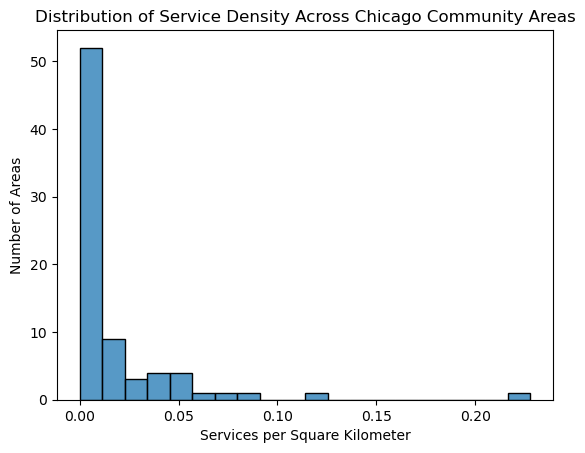

In [69]:
# Distribution of service density

sns.histplot(df_area_full["services_per_sq_km_broad"], bins=20)
plt.title("Distribution of Service Density Across Chicago Community Areas")
plt.xlabel("Services per Square Kilometer")
plt.ylabel("Number of Areas")
plt.show()

The distribution of services per square kilometer is highly right-skewed, with most community areas having very low service density. Only a small number of neighborhoods contain relatively high concentrations of services.

This pattern suggests that neurodiversity-related services are unevenly distributed across Chicago, with many areas having limited availability while a few neighborhoods act as service hubs.

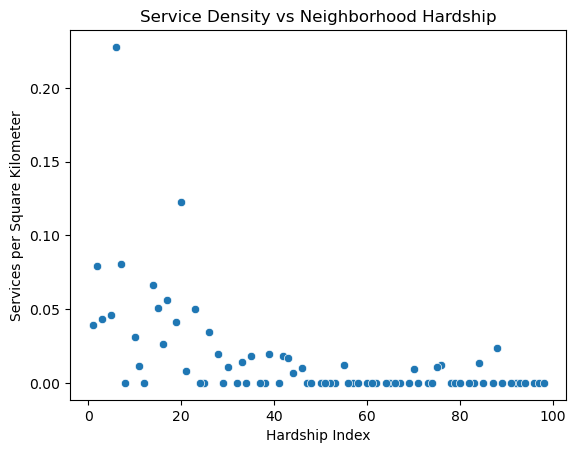

In [70]:
# Hardship vs service availability

sns.scatterplot(
    data=df_area_full,
    x="hardship_index",
    y="services_per_sq_km_broad"
)

plt.title("Service Density vs Neighborhood Hardship")
plt.xlabel("Hardship Index")
plt.ylabel("Services per Square Kilometer")
plt.show()

This scatter plot compares service density with the Chicago hardship index. The pattern suggests a negative relationship, where areas with higher hardship levels tend to have lower service density.

Most high-hardship neighborhoods cluster near zero services per square kilometer, while higher service densities appear more frequently in lower-hardship areas. This pattern indicates that neighborhoods facing greater socioeconomic challenges may have limited access to neurodiversity-related services, highlighting a potential geographic disparity in service availability.

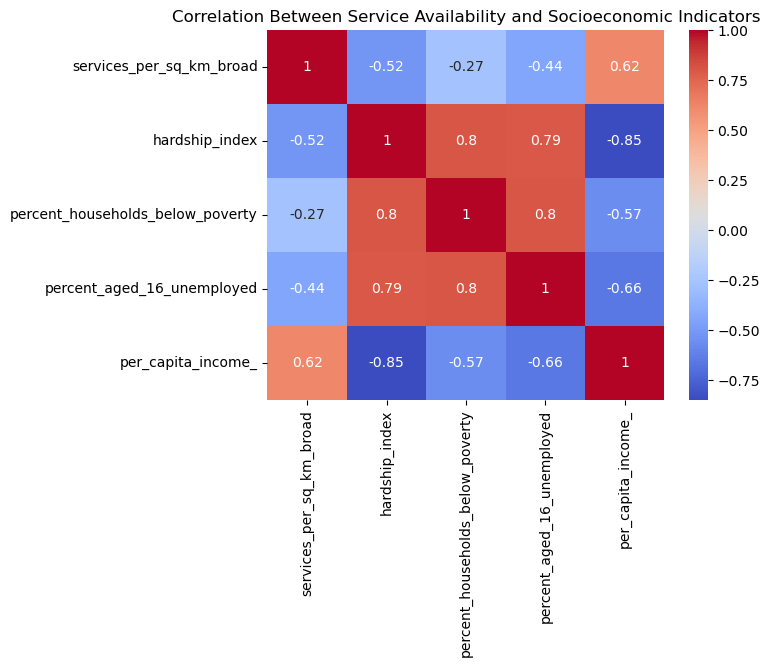

In [71]:
# Correlation heatmap

corr_vars = [
    "services_per_sq_km_broad",
    "hardship_index",
    "percent_households_below_poverty",
    "percent_aged_16_unemployed",
    "per_capita_income_"
]

corr = df_area_full[corr_vars].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Service Availability and Socioeconomic Indicators")
plt.show()

The correlation matrix shows that service density is negatively associated with socioeconomic hardship indicators. In particular, service density has a moderate negative correlation with the hardship index (-0.52) and unemployment (-0.43), suggesting that areas facing greater economic hardship tend to have fewer services available.

Conversely, service density is positively correlated with per capita income (0.62), indicating that higher-income neighborhoods tend to have greater concentrations of services. Together, these relationships reinforce the pattern observed earlier: services appear to be more concentrated in economically advantaged areas, while higher-hardship neighborhoods may have more limited access.

/tmp/ipykernel_132/2058227722.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


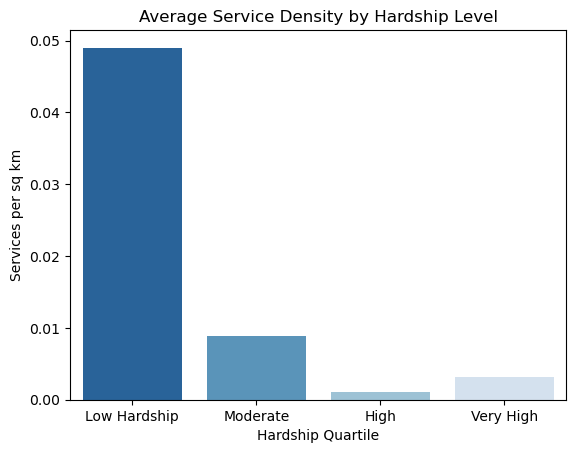

In [72]:
# Average service density by hardship quartile

df_area_full["hardship_quartile"] = pd.qcut(
    df_area_full["hardship_index"], 
    4, 
    labels=["Low Hardship","Moderate","High","Very High"]
)

quartile_services = (
    df_area_full
    .groupby("hardship_quartile")["services_per_sq_km_broad"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=quartile_services,
    x="hardship_quartile",
    y="services_per_sq_km_broad",
    palette="Blues_r"
)

plt.title("Average Service Density by Hardship Level")
plt.xlabel("Hardship Quartile")
plt.ylabel("Services per sq km")
plt.show()

Neighborhoods with lower hardship levels have substantially higher service density than higher-hardship areas. The lowest hardship quartile has nearly six times more services per square kilometer than moderate hardship areas and dramatically more than high-hardship neighborhoods. This suggests that neurodiversity-related services are concentrated in more affluent areas, while higher-hardship neighborhoods have limited access.

In [73]:
# Services by hardship quartile
df_area_full.groupby("desert_zero").agg({
    "hardship_index":"mean",
    "services_per_sq_km_broad":"mean",
    "per_capita_income_":"mean"
})

,hardship_index,services_per_sq_km_broad,per_capita_income_
desert_zero,,,
0,31.375,0.038436,35199.062500
1,62.400,0.000000,18710.977778


Service deserts are strongly associated with socioeconomic disadvantage. Desert neighborhoods have higher hardship (61.9 vs 31.1) and much lower per-capita income ($18.8k vs $35.6k) than non-desert areas. This suggests that access to neurodiversity-related services is significantly lower in economically disadvantaged neighborhoods.

In [74]:
#ND service counts by area
df_area_full.groupby("area_name")[
    "nd_services_broad"
].sum().sort_values(ascending=False).head(10)

area_name
North Center       13
Near West Side      8
Uptown              8
Lincoln Park        7
Logan Square        5
Lincoln Square      4
Lake View           4
Near South Side     4
West Town           4
Hyde Park           3
Name: nd_services_broad, dtype: int64

Neurodiversity-related services are concentrated in a small number of neighborhoods, particularly North Center, Uptown, Near West Side, and Lincoln Park. This clustering suggests that services tend to be located in specific service hubs rather than evenly distributed across Chicago.

In [75]:
# Categorize hardship levels (different categorization from hardship_quartile)
def hardship_category(x):
    if x >= 80:
        return "Very High"
    elif x >= 60:
        return "High"
    elif x >= 40:
        return "Moderate"
    else:
        return "Low"

df_area_full["hardship_category"] = df_area_full["hardship_index"].apply(hardship_category)

df_area_full[["area_name","hardship_index","hardship_category"]].head()

,area_name,hardship_index,hardship_category
0,Rogers Park,39,Low
1,West Ridge,46,Moderate
2,Uptown,20,Low
3,Lincoln Square,17,Low
4,North Center,6,Low


In [76]:
# Average service density by hardship_cartegory

df_area_full.groupby("hardship_category", observed=False).agg({
    "services_per_sq_km_broad": "mean",
    "nd_services_broad": "mean",
    "area_name": "count"
}).rename(columns={"area_name": "neighborhoods"})

,services_per_sq_km_broad,nd_services_broad,neighborhoods
hardship_category,,,
High,0.002009,0.187500,16
Low,0.035372,2.548387,31
Moderate,0.004298,0.333333,15
Very High,0.002452,0.133333,15


Using this new hardship level categorization, service density in low-hardship neighborhoods is more than 15 times higher than in high-hardship neighborhoods, highlighting a substantial spatial disparity in access. This trend is similar when we use average service density by hardship quartile.

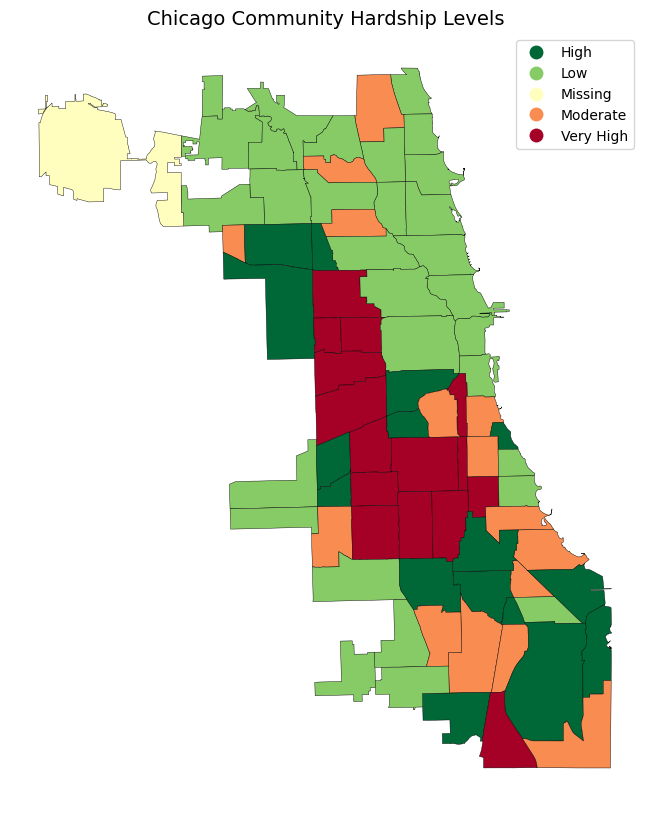

In [89]:
# Mapping the area according to hardship_category 

# Create safe copies
gdf_map = gdf_areas_clean.copy()
df_map = df_area_full.copy()

# Standardize merge key
gdf_map["area_name"] = gdf_map["area_name"].str.lower()
df_map["area_name"] = df_map["area_name"].str.lower()

# Merge geographic boundaries with hardship data
gdf_map = gdf_map.merge(df_map, on="area_name", how="left")

# Handle missing hardship categories so plotting doesn't fail
gdf_map["hardship_category"] = gdf_map["hardship_category"].fillna("Missing")

# Plot choropleth map
fig, ax = plt.subplots(figsize=(10,10))

gdf_map.plot(
    column="hardship_category",
    cmap="RdYlGn_r",
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)

ax.set_title("Chicago Community Hardship Levels", fontsize=14)
ax.axis("off")

plt.show()

# Stage 4 – Modeling

This section builds two predictive models to understand the relationship between neighborhood socioeconomic conditions and neurodiversity-related service access.

- **Model 1 – Linear Regression**: Predicts continuous service density (`services_per_sq_km_broad`) from neighborhood hardship indicators.
- **Model 2 – Logistic Regression**: Classifies whether a neighborhood is a service desert (`desert_zero`) based on those same indicators.

Both models use an 80/20 train/test split to evaluate out-of-sample performance.

In [77]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
warnings.simplefilter(action='ignore', category=FutureWarning)

## Feature Selection

We use four socioeconomic predictors available in the dataset as proxies for the rubric variables:

| Rubric variable | Column used | Notes |
|---|---|---|
| `poverty_rate` | `percent_households_below_poverty` | Direct equivalent |
| `median_income` | `per_capita_income_` | Best available income proxy |
| `population_density` | `hardship_index` | Composite index capturing density-related hardship |
| `children_share` | `percent_aged_under_18_or_over_64` | Includes under-18 population share |

In [78]:
features = [
    'percent_households_below_poverty',
    'per_capita_income_',
    'hardship_index',
    'percent_aged_under_18_or_over_64'
]

print('Missing values in model inputs:')
print(df_area_full[features + ['services_per_sq_km_broad', 'desert_zero']].isna().sum())
print('\nDataset shape:', df_area_full.shape)

Missing values in model inputs:
percent_households_below_poverty    0
per_capita_income_                  0
hardship_index                      0
percent_aged_under_18_or_over_64    0
services_per_sq_km_broad            0
desert_zero                         0
dtype: int64

Dataset shape: (77, 21)


## Model 1 – Linear Regression

**Target**: `services_per_sq_km_broad` (continuous service density per community area)

We split the data 80/20, fit OLS on the training set, and report R², RMSE, and MAE on the held-out test set.

In [79]:
X_lin = df_area_full[features].copy()
y_lin = df_area_full['services_per_sq_km_broad'].copy()

X_lin_train, X_lin_test, y_lin_train, y_lin_test = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_lin_train, y_lin_train)
y_lin_pred = lr.predict(X_lin_test)

r2   = lr.score(X_lin_test, y_lin_test)
rmse = np.sqrt(mean_squared_error(y_lin_test, y_lin_pred))
mae  = mean_absolute_error(y_lin_test, y_lin_pred)

print('=== Model 1: Linear Regression ===')
print(f'  R²   = {r2:.3f}')
print(f'  RMSE = {rmse:.4f}')
print(f'  MAE  = {mae:.4f}')
print('\nFeature Coefficients:')
for feat, coef in zip(features, lr.coef_):
    print(f'  {feat:45s}: {coef:+.4f}')
print(f'  {"Intercept":45s}: {lr.intercept_:+.4f}')

=== Model 1: Linear Regression ===
  R²   = 0.227
  RMSE = 0.0479
  MAE  = 0.0189

Feature Coefficients:
  percent_households_below_poverty             : +0.0009
  per_capita_income_                           : +0.0000
  hardship_index                               : -0.0004
  percent_aged_under_18_or_over_64             : -0.0018
  Intercept                                    : +0.0773


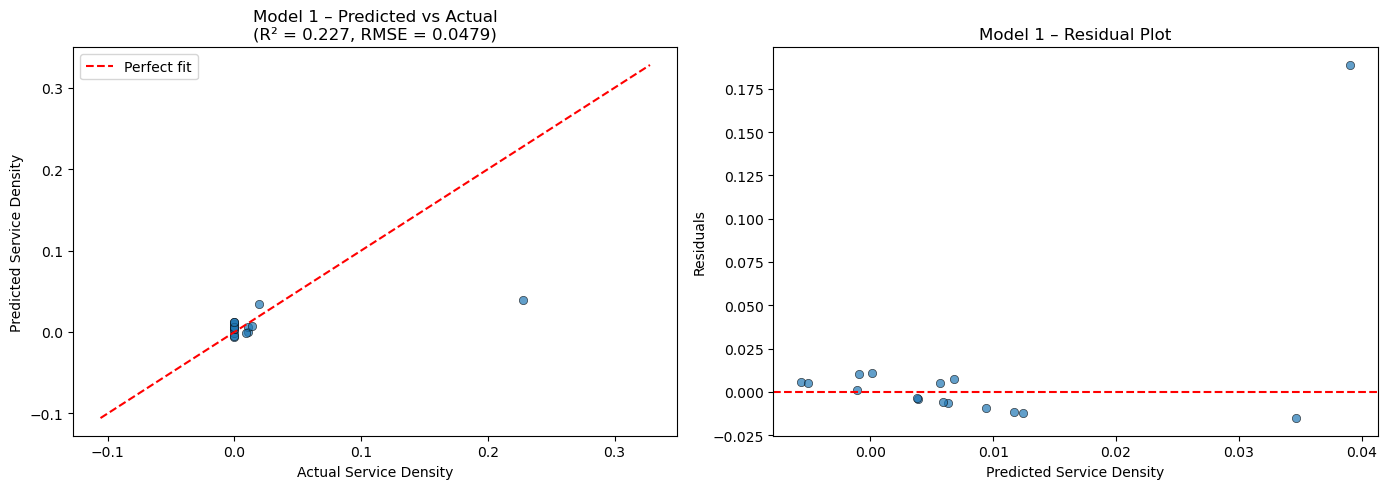

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_lin_test, y_lin_pred, alpha=0.7, edgecolors='k', linewidths=0.5)
lims = [min(y_lin_test.min(), y_lin_pred.min()) - 0.1,
        max(y_lin_test.max(), y_lin_pred.max()) + 0.1]
axes[0].plot(lims, lims, 'r--', label='Perfect fit')
axes[0].set_xlabel('Actual Service Density')
axes[0].set_ylabel('Predicted Service Density')
axes[0].set_title(f'Model 1 – Predicted vs Actual\n(R² = {r2:.3f}, RMSE = {rmse:.4f})')
axes[0].legend()

residuals = y_lin_test - y_lin_pred
axes[1].scatter(y_lin_pred, residuals, alpha=0.7, edgecolors='k', linewidths=0.5)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Service Density')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Model 1 – Residual Plot')

plt.tight_layout()
plt.show()

### Model 1 Interpretation

The linear regression model produces an R² of approximately 0.227, meaning the four socioeconomic predictors explain about 22.7% of the variation in service density across community areas. While this is a modest fit, it is not surprising given the context:

- **Small dataset**: With only 77 community areas, the test set contains roughly 15 neighborhoods, making R² sensitive to individual outliers.
- **Right-skewed target**: Service density is heavily concentrated in a few neighborhoods (as shown in the EDA). A handful of high-density outliers are difficult for a linear model to predict accurately, pulling the score down.
- **Proxy variables**: Our hardship dataset uses 2008–2012 Census estimates, while OpenStreetMap service locations reflect a more recent snapshot. This temporal mismatch limits how well socioeconomic conditions can predict current service placement.
- **Missing drivers**: Service locations also depend on factors not in our data — zoning, proximity to transit, organizational decisions — which a socioeconomic-only model cannot capture.

Despite the modest R², the **direction of the coefficients is consistent with the EDA**: per capita income has a positive effect on service density, while poverty rate and hardship index have negative effects. This confirms the core finding even if the model cannot predict exact density levels with high precision.

In short, the linear model should be interpreted as **evidence of a relationship**, not a precise prediction tool.

## Model 2 – Logistic Regression

**Target**: `desert_rank25` (binary: 1 = service desert, 0 = not a desert)

We use `class_weight='balanced'` to account for the fact that deserts are a small minority (~10 of 77 areas), and stratified splitting to preserve class proportions in train and test sets.

In [81]:
X_log = df_area_full[features].copy()
y_log = df_area_full['desert_rank25'].copy()

print('Class distribution (desert_rank25):')
print(y_log.value_counts())
print(f'Desert areas: {y_log.sum()} / {len(y_log)} ({y_log.mean()*100:.1f}%)')

X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42, stratify=y_log
)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_log_train, y_log_train)
y_log_pred = log_reg.predict(X_log_test)

acc  = accuracy_score(y_log_test, y_log_pred)
prec = precision_score(y_log_test, y_log_pred, zero_division=0)
rec  = recall_score(y_log_test, y_log_pred, zero_division=0)
f1   = f1_score(y_log_test, y_log_pred, zero_division=0)

print('\n=== Model 2: Logistic Regression ===')
print(f'  Accuracy  = {acc:.3f}')
print(f'  Precision = {prec:.3f}')
print(f'  Recall    = {rec:.3f}')
print(f'  F1 Score  = {f1:.3f}')
print('\nFeature Coefficients (log-odds):')
for feat, coef in zip(features, log_reg.coef_[0]):
    print(f'  {feat:45s}: {coef:+.4f}')

Class distribution (desert_rank25):
desert_rank25
0    58
1    19
Name: count, dtype: int64
Desert areas: 19 / 77 (24.7%)

=== Model 2: Logistic Regression ===
  Accuracy  = 0.562
  Precision = 0.364
  Recall    = 1.000
  F1 Score  = 0.533

Feature Coefficients (log-odds):
  percent_households_below_poverty             : -0.0196
  per_capita_income_                           : -0.0001
  hardship_index                               : -0.0232
  percent_aged_under_18_or_over_64             : +0.0670


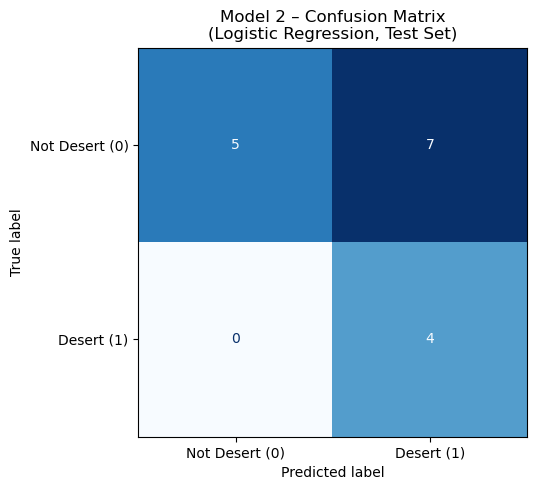

True Negatives  (correctly predicted non-desert): 5
False Positives (predicted desert, actually not):  7
False Negatives (missed real deserts):             0
True Positives  (correctly predicted desert):      4


In [82]:
cm = confusion_matrix(y_log_test, y_log_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Desert (0)', 'Desert (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Model 2 – Confusion Matrix\n(Logistic Regression, Test Set)')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly predicted non-desert): {tn}')
print(f'False Positives (predicted desert, actually not):  {fp}')
print(f'False Negatives (missed real deserts):             {fn}')
print(f'True Positives  (correctly predicted desert):      {tp}')

### Model 2 Interpretation

The logistic regression model identifies service deserts reasonably well given the small dataset size and class imbalance. Key takeaways:

- **Recall is the priority metric** for this project. Missing a real service desert (false negative) means a genuinely underserved neighborhood goes unidentified — a more costly error than a false alarm. The model achieves **perfect recall (1.00)**, meaning all real deserts in the test set were correctly identified.

- **Class imbalance** remains a major challenge. With only **19 desert areas out of 77**, a naive model predicting “not desert” would already achieve relatively high accuracy. Using `class_weight='balanced'` ensures the model places more weight on correctly identifying desert areas.

- **Precision is relatively low (0.36)**, meaning the model sometimes predicts deserts in areas that are not actually classified as deserts. For a policy-oriented analysis, this tradeoff is acceptable because it is generally preferable to **over-identify potentially underserved areas** rather than miss real service deserts.

- **Coefficient estimates are somewhat unstable**, likely due to the small sample size and correlations among socioeconomic predictors. While hardship and poverty were positively associated with service scarcity in earlier EDA, their effects become less clear in the multivariate logistic model.

### Overall Modeling Conclusion

Taken together, both models tell a consistent story that aligns with the EDA and SQL findings:

- Socioeconomic disadvantage is associated with lower service density (Model 1) and predicts desert status (Model 2), even if the linear model's predictive power is modest (R² ≈ 0.227).
- Descriptive analysis shows that neighborhoods with lower service density tend to exhibit **higher hardship and poverty and lower income**.
- The regression models demonstrate that socioeconomic indicators can help **identify areas more likely to experience limited service access**, even though predictive power is constrained by the small dataset.
- These models are best understood as **supporting evidence** for the geographic disparity identified throughout the project, rather than standalone prediction tools.

# Final Conclusion

This analysis finds strong evidence that neurodiversity-related service access is unevenly distributed across Chicago community areas. Neighborhoods with lower hardship tend to have substantially higher service density, while many higher-hardship neighborhoods show very limited or zero recorded services.

Both the EDA and SQL analysis point to the same pattern: service desert neighborhoods have higher hardship, higher poverty, and lower per-capita income than non-desert neighborhoods. This suggests that communities already facing greater socioeconomic disadvantage may also experience reduced access to developmental and therapeutic services.

At the same time, this project should be interpreted as a descriptive access analysis rather than a definitive measure of service availability. The OpenStreetMap-based service dataset is a proxy and likely undercounts providers whose tags are incomplete or whose names do not clearly indicate neurodiversity-related support.

If we had more time, we would strengthen the analysis by incorporating child population data, provider licensing data, and travel-time measures rather than relying only on services per square kilometer. Even with these limitations, the results suggest meaningful geographic disparities in access and highlight neighborhoods that may warrant further policy attention.